# Bài tập 1: Neural Style Transfer với TensorFlow

In [1]:
import os
import time
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request


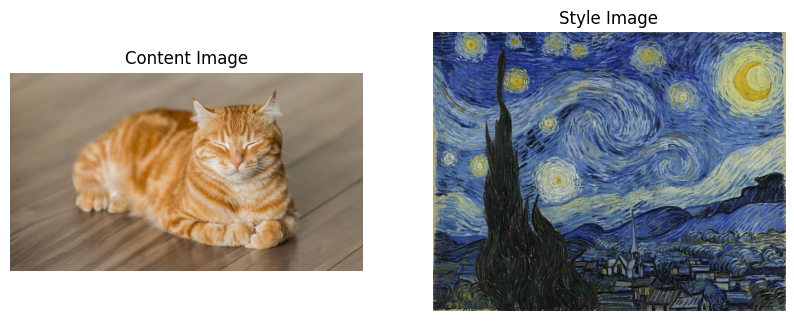

In [ ]:
# load ảnh content và style lên
def download_sample_images():
    content_url = 'https://upload.wikimedia.org/wikipedia/commons/d/d7/Green_Sea_Turtle_grazing_seagrass.jpg'
    style_url = 'https://upload.wikimedia.org/wikipedia/commons/0/0a/The_Great_Wave_off_Kanagawa.jpg'
    content_path = r'C:\Users\Admin\Desktop\DAT301m\bt1\hinh-nen-meo.jpg'
    style_path = r'C:\Users\Admin\Desktop\DAT301m\bt1\â.png'
    if not os.path.exists(content_path):
        print("Đang tải ảnh Content mẫu...")
        urllib.request.urlretrieve(content_url, content_path)
    if not os.path.exists(style_path):
        print("Đang tải ảnh Style mẫu...")
        urllib.request.urlretrieve(style_url, style_path)
    return content_path, style_path

content_path, style_path = download_sample_images()

# In ảnh mẫu để kiếm tra
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(Image.open(content_path))
plt.title("Content Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(Image.open(style_path))
plt.title("Style Image")
plt.axis('off')
plt.show()


## 2. Tiền xử lý và trích xuất đặc trưng


In [ ]:
def load_img(path_to_img, target_size=(256, 256)):
    """Đọc ảnh từ đường dẫn, chuẩn hóa và chuẩn bị cho mô hình."""
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, target_size)
    img = img * 255.0   # Đưa về thang [0, 255] cho VGG19
    img = img[tf.newaxis, :]
    return img

def preprocess_image(img):
    """Tiền xử lý ảnh theo chuẩn của mạng VGG19."""
    # Sử dụng hàm tiện ích của Keras dành riêng cho VGG19 để:
    # - Chuyển hệ màu từ RGB sang BGR
    # - Trừ đi giá trị trung bình (mean) của tập dữ liệu ImageNet (zero-centering)
    return tf.keras.applications.vgg19.preprocess_input(img)

In [ ]:
CONTENT_LAYERS = ['block5_conv2'] # Lớp sâu để lấy cấu trúc nội dung (Content)
STYLE_LAYERS = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
] # Các lớp trải dài từ nông đến sâu để lấy phong cách (Style) ở nhiều quy mô

def vgg_layers(layer_names):
    """Tạo một mô hình trung gian trả về đầu ra của các lớp cụ thể trong VGG19."""
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet') # Tải mô hình VGG19 đã huấn luyện sẵn trên ImageNet, bỏ phần phân loại (Top)
    vgg.trainable = False # Đóng băng các trọng số vì chúng ta chỉ dùng VGG19 làm bộ trích xuất đặc trưng
    outputs = [vgg.get_layer(name).output for name in layer_names] # Lấy đầu ra (output) của các lớp đã chỉ định trong layer_names
    return tf.keras.Model([vgg.input], outputs)  # Trả về một model mới: Đầu vào là ảnh, đầu ra là danh sách các feature maps

def gram_matrix(input_tensor):
    """Tính toán Ma trận Gram để đo lường sự tương quan giữa các kênh đặc trưng."""
    # Sử dụng phép toán Einstein summation để tính tích vô hướng giữa các kênh
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor) # 'bijc' là (batch, i, j, channel). Kết quả 'bcd' là (batch, channel, channel)
    # Lấy kích thước (số lượng pixel) của feature map
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result / num_locations # Chuẩn hóa ma trận Gram bằng cách chia cho tổng số pixel


In [ ]:
class StyleContentModel(tf.keras.models.Model):
    """Khởi tạo mô hình"""
    def __init__(self, style_layers, content_layers):
        super(StyleContentModel, self).__init__()
        self.vgg = vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False

    def call(self, inputs):
        """Hàm thực thi chính khi truyền ảnh qua mô hình."""
        outputs = self.vgg(inputs)
        style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                          outputs[self.num_style_layers:])
        style_outputs = [gram_matrix(s) for s in style_outputs]
        content_dict = {n:v for n, v in zip(self.content_layers, content_outputs)}
        style_dict = {n:v for n, v in zip(self.style_layers, style_outputs)}
        return {'content': content_dict, 'style': style_dict}


In [ ]:
CONTENT_WEIGHT = 2.5e-8
STYLE_WEIGHT = 1.0e-6
TV_WEIGHT = 1.0e-6
ITERATIONS = 9000

def compute_loss(outputs, style_targets, content_targets, style_weight=STYLE_WEIGHT, content_weight=CONTENT_WEIGHT):
    '''Tính Loss cho mô hình'''
    style_outputs = outputs['style']
    content_outputs = outputs['content']
    
    style_loss = tf.add_n([tf.reduce_mean((style_outputs[name] - style_targets[name])**2)
                           for name in style_outputs.keys()])
    style_loss *= style_weight / len(STYLE_LAYERS)

    content_loss = tf.add_n([tf.reduce_mean((content_outputs[name] - content_targets[name])**2)
                             for name in content_outputs.keys()])
    content_loss *= content_weight / len(CONTENT_LAYERS)
    
    return style_loss + content_loss


## 4. Training Loop: So sánh kết quả qua các mốc huấn luyện


Chạy huấn luyện với Style Weight = 1e-06
Các mốc hiển thị: [100, 3100, 6000, 9000]
Bước 100/9000 - Loss: 1695.4745 - Thời gian: 91.9s
Bước 200/9000 - Loss: 623.1164 - Thời gian: 94.3s
Bước 300/9000 - Loss: 300.4344 - Thời gian: 96.6s
Bước 400/9000 - Loss: 172.7475 - Thời gian: 98.9s
Bước 500/9000 - Loss: 116.2996 - Thời gian: 101.3s
Bước 600/9000 - Loss: 89.4454 - Thời gian: 103.6s
Bước 700/9000 - Loss: 74.6863 - Thời gian: 106.0s
Bước 800/9000 - Loss: 65.4924 - Thời gian: 108.4s
Bước 900/9000 - Loss: 59.2010 - Thời gian: 110.7s
Bước 1000/9000 - Loss: 54.6002 - Thời gian: 113.1s
Bước 1100/9000 - Loss: 51.0243 - Thời gian: 115.4s
Bước 1200/9000 - Loss: 48.1410 - Thời gian: 117.7s
Bước 1300/9000 - Loss: 45.7283 - Thời gian: 120.1s
Bước 1400/9000 - Loss: 43.6714 - Thời gian: 122.4s
Bước 1500/9000 - Loss: 41.8945 - Thời gian: 124.8s
Bước 1600/9000 - Loss: 40.3419 - Thời gian: 127.1s
Bước 1700/9000 - Loss: 38.9719 - Thời gian: 129.5s
Bước 1800/9000 - Loss: 37.7614 - Thời gian: 131.8s
Bước 1

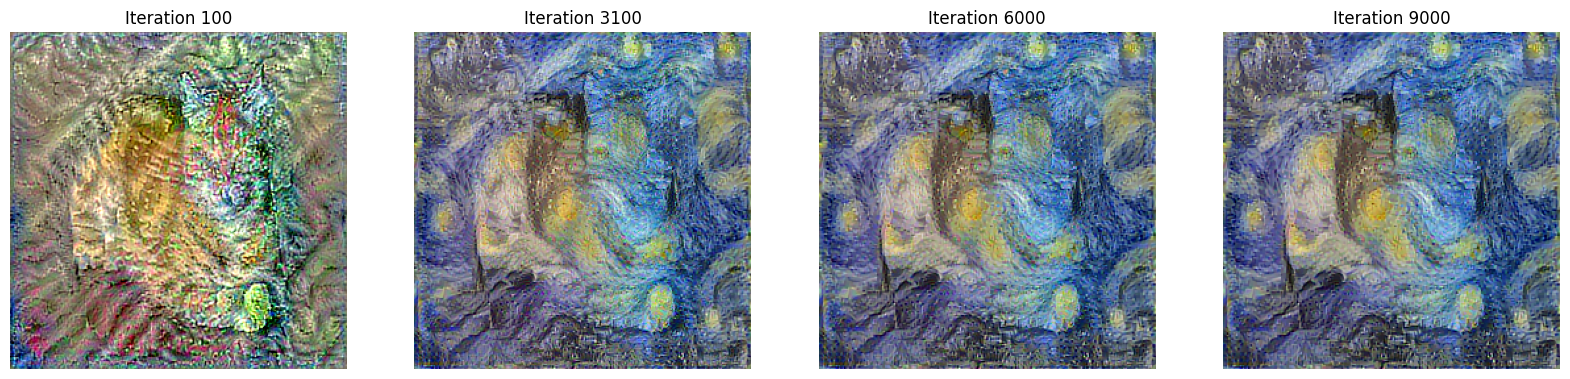

In [ ]:
def run_style_transfer(content_path, style_path, iterations=ITERATIONS, style_weight=STYLE_WEIGHT):
    # Tải và chuẩn bị ảnh đầu vào
    content_image = load_img(content_path)
    style_image = load_img(style_path)

    # Khởi tạo bộ trích xuất đặc trưng và tính toán các mục tiêu (targets) cố định
    extractor = StyleContentModel(STYLE_LAYERS, CONTENT_LAYERS)
    style_targets = extractor(preprocess_image(style_image))['style']
    content_targets = extractor(preprocess_image(content_image))['content']

    # Biến quan trọng nhất: Khởi tạo ảnh sẽ tối ưu hóa (bắt đầu từ ảnh Content)
    image = tf.Variable(content_image)
    opt = tf.keras.optimizers.Adam(learning_rate=100, beta_1=0.99, epsilon=1e-1) # Bộ tối ưu hóa Adam (Learning rate cao vì giá trị pixel chạy từ 0-255)

    @tf.function()
    def train_step(image):
        with tf.GradientTape() as tape:
            outputs = extractor(preprocess_image(image)) # Trích xuất đặc trưng của ảnh hiện tại
            loss = compute_loss(outputs, style_targets, content_targets, style_weight=style_weight) # Tính toán Content Loss và Style Los
            loss += TV_WEIGHT * tf.image.total_variation(image) # Cộng thêm Total Variation Loss để khử nhiễu, giúp ảnh mịn hơn
        grad = tape.gradient(loss, image) # Tính đạo hàm của Loss theo từng Pixel ảnh
        opt.apply_gradients([(grad, image)]) # Cập nhật các pixel ảnh dựa trên đạo hàm
        image.assign(tf.clip_by_value(image, 0.0, 255.0)) # Đảm bảo giá trị pixel không vượt quá khoảng [0, 255]
        return loss
    
    start_time = time.time()
    images_to_display = []
    titles = []
    
    # Tự động tính 4 mốc chia đều (làm tròn về bội 100)
    step = (iterations - 100) // 3
    milestones = [
        100,
        round((100 + step) / 100) * 100,
        round((100 + 2 * step) / 100) * 100,
        round(iterations / 100) * 100
    ]
    # Đảm bảo mốc cuối = iterations nếu iterations chia hết cho 100
    if iterations % 100 == 0:
        milestones[-1] = iterations
    print(f"Các mốc hiển thị: {milestones}")

    for i in range(1, iterations + 1):
        loss = train_step(image)
        if i % 100 == 0:
            elapsed = time.time() - start_time
            print(f"Bước {i}/{iterations} - Loss: {loss[0]:.4f} - Thời gian: {elapsed:.1f}s")
            if i in milestones:
                out_img = np.clip(np.squeeze(image.numpy(), 0), 0, 255).astype("uint8")
                images_to_display.append(out_img)
                titles.append(f"Iteration {i}")

    plt.figure(figsize=(20, 5))
    for idx in range(len(images_to_display)):
        plt.subplot(1, len(images_to_display), idx+1)
        plt.imshow(images_to_display[idx])
        plt.title(titles[idx])
        plt.axis('off')
    plt.show()

print("Chạy huấn luyện với Style Weight =", STYLE_WEIGHT)
run_style_transfer(content_path, style_path)


## 5. Thử nghiệm thay đổi trọng số (Style Weight)

Thử giảm `style_weight` xuống 10 lần (từ `1.0e-6` → `1.0e-7`)


Chạy huấn luyện với Style Weight mới = 1e-07
Các mốc hiển thị: [100, 3100, 6000, 9000]
Bước 100/9000 - Loss: 727.3370 - Thời gian: 3.2s
Bước 200/9000 - Loss: 262.0495 - Thời gian: 5.7s
Bước 300/9000 - Loss: 132.6595 - Thời gian: 8.1s
Bước 400/9000 - Loss: 84.3841 - Thời gian: 10.5s
Bước 500/9000 - Loss: 62.5688 - Thời gian: 13.0s
Bước 600/9000 - Loss: 50.7313 - Thời gian: 15.4s
Bước 700/9000 - Loss: 43.3686 - Thời gian: 17.8s
Bước 800/9000 - Loss: 38.4480 - Thời gian: 20.2s
Bước 900/9000 - Loss: 34.9456 - Thời gian: 22.5s
Bước 1000/9000 - Loss: 32.2872 - Thời gian: 24.9s
Bước 1100/9000 - Loss: 30.1887 - Thời gian: 27.3s
Bước 1200/9000 - Loss: 28.4680 - Thời gian: 29.6s
Bước 1300/9000 - Loss: 27.0342 - Thời gian: 32.0s
Bước 1400/9000 - Loss: 25.8170 - Thời gian: 34.4s
Bước 1500/9000 - Loss: 24.7582 - Thời gian: 36.7s
Bước 1600/9000 - Loss: 23.8230 - Thời gian: 39.1s
Bước 1700/9000 - Loss: 22.9931 - Thời gian: 41.4s
Bước 1800/9000 - Loss: 22.2561 - Thời gian: 43.8s
Bước 1900/9000 - Loss:

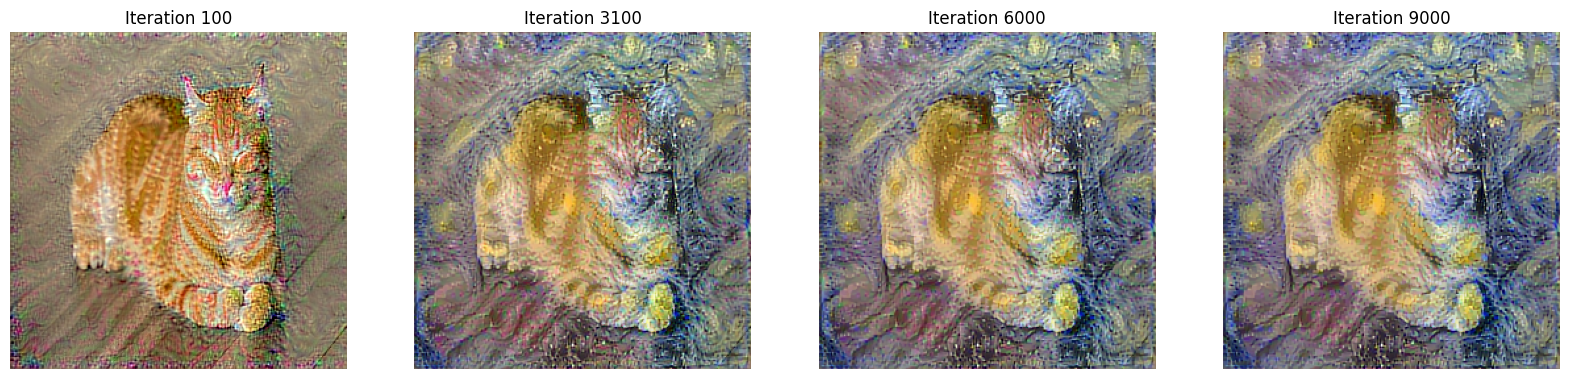

In [ ]:
NEW_STYLE_WEIGHT = 1.0e-7
print("Chạy huấn luyện với Style Weight mới =", NEW_STYLE_WEIGHT)
run_style_transfer(content_path, style_path, iterations=9000, style_weight=NEW_STYLE_WEIGHT)

# Trả lời câu hỏi

**câu 1: Giải thích lựa chọn: Tại sao các chọn các lớp (layers) cụ thể trong mạng VGG19 để tính toán Style Loss?**

- Việc lựa chọn các lớp cụ thể trong mạng VGG19 dựa trên khả năng trích xuất đặc trưng phân cấp của mạng thần kinh nhân tạo CNN. Các lớp nông ở phía đầu mạng (như block1_conv1, block2_conv1) đóng vai trò nhận diện các chi tiết vi mô như nét cọ đơn lẻ, kết cấu bề mặt và các điểm màu sắc nhỏ. Trong khi đó, các lớp sâu hơn ở phía cuối mạng (như block4_conv1, block5_conv1) lại tập trung vào các đặc trưng trừu tượng cấp cao như hoa văn lặp lại, mảng miếng bố cục và cấu trúc hình khối tổng thể của phong cách nghệ thuật.
- Phong cách nghệ thuật không nằm ở một vị trí cố định mà là sự xuất hiện đồng thời của các đặc trưng màu sắc và nét vẽ trên toàn bộ bức tranh. Tại mỗi lớp được chọn, chúng ta không so sánh trực tiếp vị trí các điểm ảnh (vì như vậy sẽ thành so sánh nội dung), mà sử dụng ma trận Gram để tính toán sự tương quan giữa các kênh đặc trưng. Việc này giúp loại bỏ hoàn toàn thông tin về không gian (vật thể nằm ở đâu) và chỉ giữ lại "essence" của phong cách (màu này thường đi với nét vẽ nào), biến các bản đồ đặc trưng thành một bản tóm tắt thống kê về kết cấu bề mặt.

**câu 2: So sánh kết quả: Hiển thị ảnh kết quả sau các mốc 1100, 3100, 6000, 9000 vòng lặp để thấy sự tiến triển.**

- Về kết quả với chỉ số style_weight = 1e-6: 
  - loss cuối ~ 19.35
  - phong cách (style) mạnh và chiếm ưu thế
  - nội dung (content) khó nhận diện về sau do bị style xâm chiếm nhiều hơn
- đánh giá: ảnh thiên về nghệ thuật hơn

**câu 3: Thử nghiệm trọng số: Thử thay đổi style_weight và nhận xét về sự thay đổi của tác phẩm nghệ thuật thu được.**

- khi thay đổi style_weight = 1e-7:
  - loss cuối ~ 10.99: thấp hơn so với style_weight = 1e-6 (19.35)
  - phong cách (style): hài hòa hơn, có sự cân bằng giữa content và style
  - nội dung (content): vẫn giữ được độ nhận diện của vật thể gốc, vó thể nhận diện vật thể gốc rõ ràng hơn
- đánh giá: cân bằng và tự nhiên hơn

**câu 4: Phân tích kĩ thuật: Nêu vai trò của tf.GradientTape trong việc cập nhật điểm ảnh.**

Vai trò của tf.GradientTape: Trong Neural Style Transfer, mạng VGG19 được giữ cố định. Thay vì cập nhật trọng số mạng, ta cập nhật trực tiếp các pixel của bức ảnh. tf.GradientTape ghi lại forward pass để tính loss, sau đó tự động tính đạo hàm (gradient) của loss theo từng pixel. Optimizer Adam dùng gradient này để cập nhật pixel, giúp bức ảnh dần mang phong cách nghệ thuật mong muốn.

